### Day 2 Remain Python Mini Project 2 :

Scenario: Simulated Stock Trading Bot

**Objective:**
Create a Python script that simulates trading over a dataset containing historical stock prices. The bot will decide whether to buy, hold, or sell based on the momentum calculated as the difference between the current price and the average price of the last few days.


### Project Components:

1. **Data Structure**:
   - Use a list of tuples or dictionaries to simulate historical stock data with each element containing information about the stock price on a particular day.

2. **Momentum Calculation**:
   - Calculate the average price of the last N days and compare it with the current day's price to determine the momentum.

3. **Trading Decisions**:
   - Use if-else statements to make trading decisions based on the calculated momentum.

4. **Trading Simulation**:
   - Loop through the dataset and simulate trading decisions, updating the portfolio accordingly.

5. **Performance Evaluation**:
   - At the end of the simulation, calculate and print the final portfolio value and compare it with the initial value to gauge performance.

### Skills and Python Features Used:
- **Python Operators**: Use arithmetic operators to calculate averages, gains, and losses.
- **Python if-else**: Make conditional decisions based on momentum and other trading indicators.
- **Python Modules**: Use the `datetime` module for handling dates, `matplotlib` for plotting stock prices and portfolio value over time.
- **Python While Loop**: Could be used to allow the simulation to run until a certain condition is met, like a stop-loss limit.
- **Python for loop**: Iterate over each day in the stock dataset to simulate trading.




[100, 110, 121, 105, 102, 114, 107, 109, 119, 122, 116, 123, 111, 103, 126, 124, 128, 115, 118, 104, 106, 129, 113, 117, 125]
109.33333333333333  107.6
Day 5: Buying at price 102
107.0  110.4
Day 6: Selling at price 114 | Profit: 12
107.66666666666667  109.8
110.0  107.4
Day 8: Buying at price 109
111.66666666666667  110.2
116.66666666666667  114.2
119.0  114.6
120.33333333333333  117.8
116.66666666666667  118.2
Day 13: Selling at price 111 | Profit: 2
112.33333333333333  115.0
113.33333333333333  115.8
117.66666666666667  117.4
Day 16: Buying at price 124
126.0  118.4
Day 18: Selling due to stop loss at price 115 | Loss: -9
120.33333333333333  122.2
112.33333333333333  117.8
109.33333333333333  114.2
113.0  114.4
116.0  114.0
Day 23: Buying at price 113
119.66666666666667  113.8
118.33333333333333  118.0
Total Profit: 5


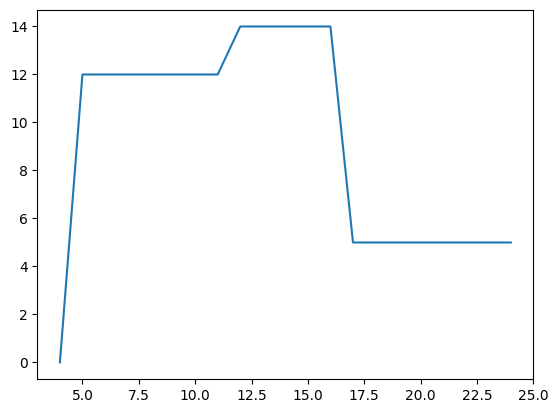

In [43]:
# generate random numbers in list between 100 to 120
import matplotlib.pyplot as plt
def auto_trader(price_tuple):
    small_avg_days = 3
    large_avg_days = 5
    if len(price_tuple) < large_avg_days:
        return "Please provide more data"
    
    # small_sum = 0
    # large_sum = 0
    already_bought = False
    last_price = 0
    total_profit = 0
    sl = 5
    x_values = []
    y_values = []
    for i in range(4,len(price_tuple)):
        x_values.append(i)
        if already_bought and (price_tuple[i] < last_price - sl):
            already_bought = False
            loss = price_tuple[i] - last_price
            total_profit += loss
            print(f"Day {i+1}: Selling due to stop loss at price {price_tuple[i]} | Loss: {loss}")
            y_values.append(total_profit)
            continue

        latest_prices = price_tuple[i-4:i+1]    
        decision = strategy(latest_prices)
        if decision == "buy":
            if already_bought:
                y_values.append(total_profit)
                continue
            else:
                already_bought = True
                last_price = price_tuple[i]
                y_values.append(total_profit)
                print(f"Day {i+1}: Buying at price {price_tuple[i]}")
        elif decision == "sell":
            if already_bought:
                already_bought = False
                profit = price_tuple[i] - last_price
                total_profit += profit
                y_values.append(total_profit)
                print(f"Day {i+1}: Selling at price {price_tuple[i]} | Profit: {profit}")
            else:
                y_values.append(total_profit)
                continue
        else:
            print(f"Day {i+1}: Holding at price {price_tuple[i]}")
            y_values.append(total_profit)
    plt.plot(x_values,y_values)
    return f"Total Profit: {total_profit}"
def strategy(price_tuple):
    small_avg_days = 3
    large_avg_days = 5
    if len(price_tuple) < large_avg_days:
        return "hold"
    small_sum_avg = sum(price_tuple[-small_avg_days:])/small_avg_days
    large_sum_avg = sum(price_tuple[-large_avg_days:])/large_avg_days
    print(f"{small_sum_avg}  {large_sum_avg}")
    if small_sum_avg > large_sum_avg:
        return "buy"
    elif small_sum_avg < large_sum_avg:
        return "sell"
    else:
        return "hold"
    
import random
price_tuple = random.sample(range(100, 130), 25)
print(price_tuple)

print(auto_trader(price_tuple))